In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../outputs/figures", exist_ok=True)

plt.style.use("seaborn-v0_8")


In [18]:
import sys
print(sys.executable)


c:\Users\Haneesh.B\AppData\Local\Programs\Python\Python311\python.exe


In [19]:
!"C:\Users\Haneesh.B\AppData\Local\Programs\Python\Python311\python.exe" -m pip install shap==0.44.1


  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 15.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/38.1 MB 18.0 MB/s eta 0:00:02
   -------- ------------------------------- 8.4/38.1 MB 19.3 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/38.1 MB 21.0 MB/s eta 0:00:02
   ------------------- -------------------- 18.6/38.1 MB 21.7 MB/s eta 0:00:01
   ----------------------- ---------------- 22.8/38.1 MB 21.8 MB/s eta 0:00:01
   ---------------------------- ----------- 27.0/38.1 MB 20.9 MB/s eta 0:00:01
   --------------------------------- ------ 31.7/38.1 MB 21.0 MB/s eta 0:00:01
   -------------------------------------- - 36.4/38.1 MB 20.9 MB/s eta 0:00:01
   ------------------------------

In [1]:
# ===============================
# SHAP – ML EXPLAINABILITY SETUP
# ===============================

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier

# Load features
X_features = np.load("../data/processed/ml_features_400.npy")

# Load labels
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
y = data["y"]

print("X shape:", X_features.shape)
print("y shape:", y.shape)

# Train Random Forest ONLY for explainability
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_features, y)

print("Random Forest trained successfully for SHAP")


X shape: (10000, 1200)
y shape: (10000,)
Random Forest trained successfully for SHAP


In [3]:
# Select a small subset for SHAP (memory-safe)
X_shap = X_features[:500]

print("X_shap shape:", X_shap.shape)


X_shap shape: (500, 1200)


In [4]:
import shap

# Tree-based SHAP (best for Random Forest)
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values computed")


SHAP values computed


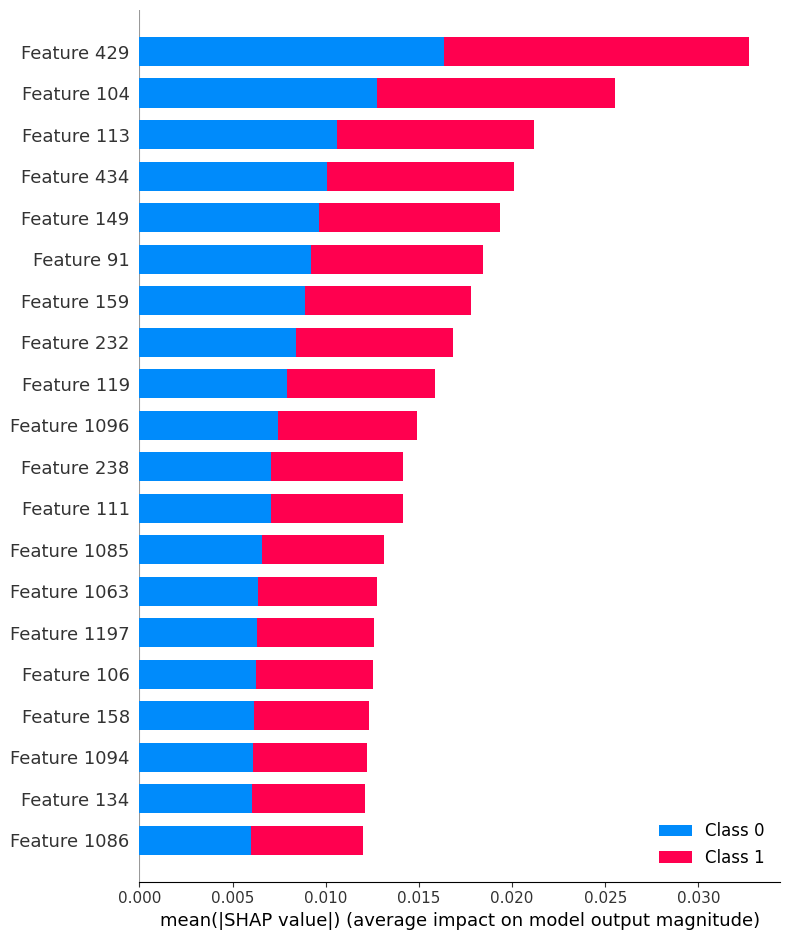

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary_ml.png", dpi=300)
plt.show()


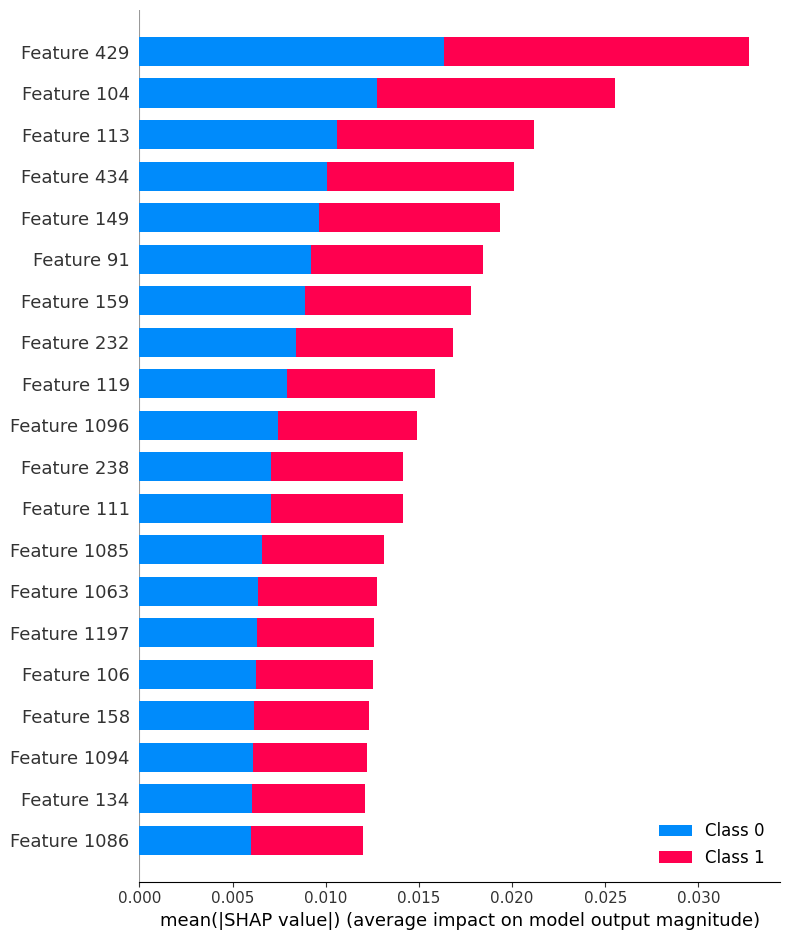

In [6]:
plt.figure(figsize=(7,4))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar_ml.png", dpi=300)
plt.show()


### ML Explainability (SHAP) – Interpretation

The SHAP analysis identifies which engineered solar features contribute
most strongly to flare prediction. Features with higher absolute SHAP
values have a greater influence on the model's output.

From a solar physics perspective, these features correspond to indicators
of magnetic field complexity, variability, and temporal instability,
which are known precursors to solar flare activity.


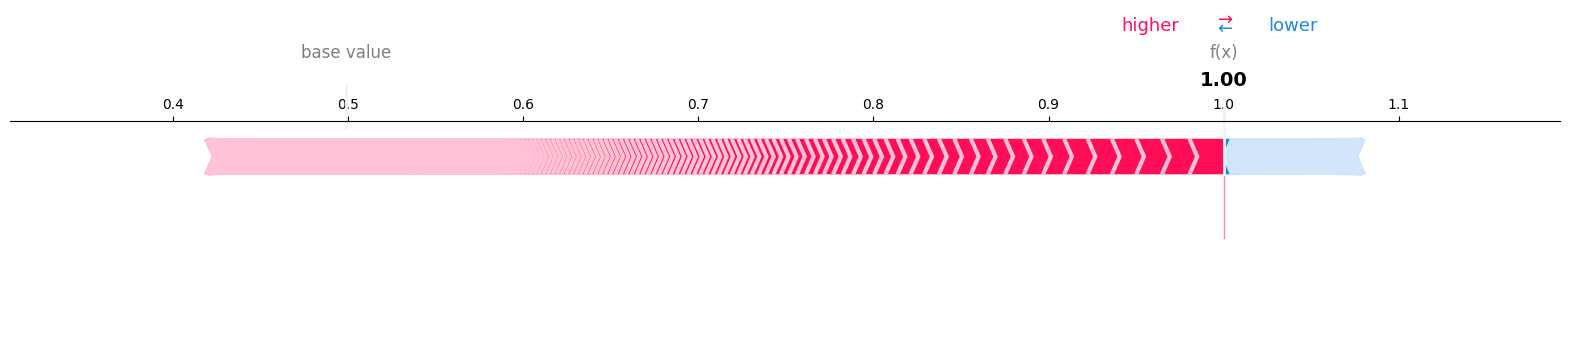

In [7]:
# Explain one individual prediction
sample_id = 0

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0][sample_id],
    X_shap[sample_id],
    matplotlib=True
)


In [8]:
plt.savefig("../outputs/figures/shap_force_sample.png", dpi=300)


<Figure size 640x480 with 0 Axes>

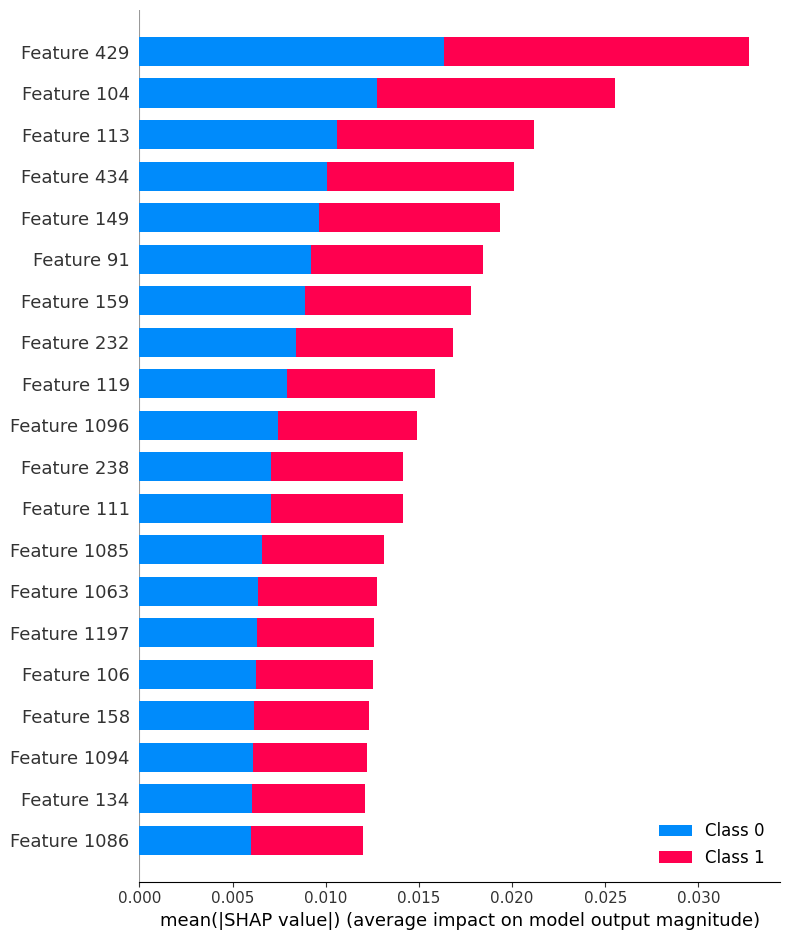

In [9]:
shap.summary_plot(shap_values, X_shap)


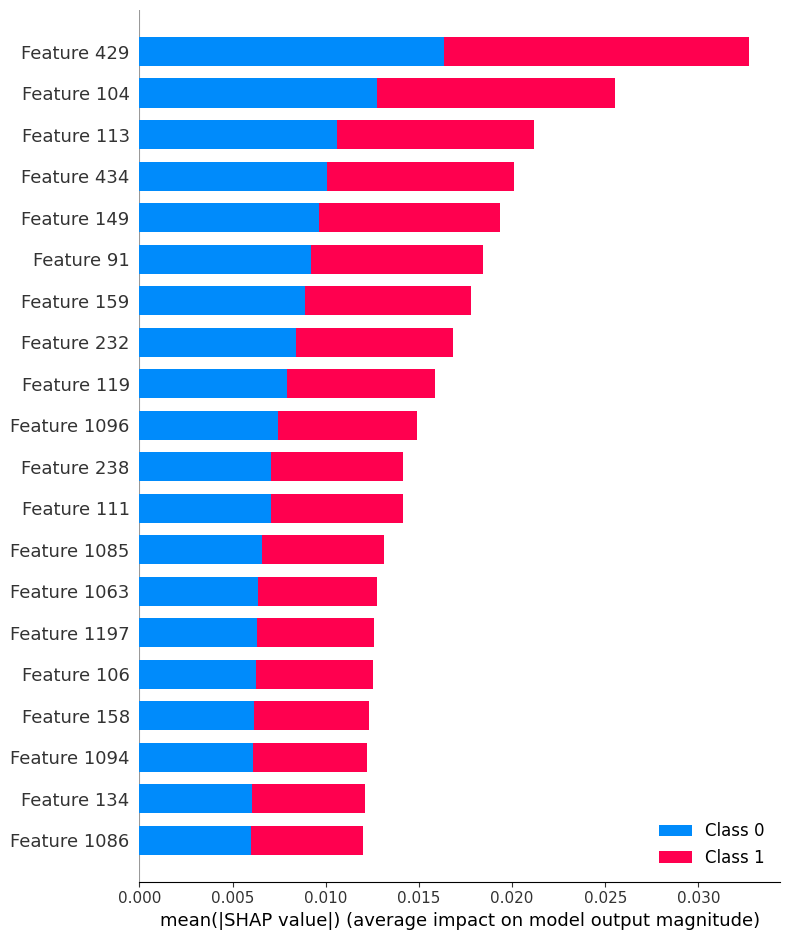

In [10]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")


In [11]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

mil_model = load_model("../outputs/models/mil_attention_model")

X_features = np.load("../data/processed/ml_features_400.npy")

def create_mil_instances(X, segments=8):
    instance_size = X.shape[1] // segments
    bags = []
    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)
    return np.array(bags)

X_bags = create_mil_instances(X_features, segments=8)


In [12]:
attention_model = tf.keras.Model(
    mil_model.input,
    mil_model.layers[1].output
)

weights = attention_model.predict(X_bags[:1], verbose=0)[0].squeeze()


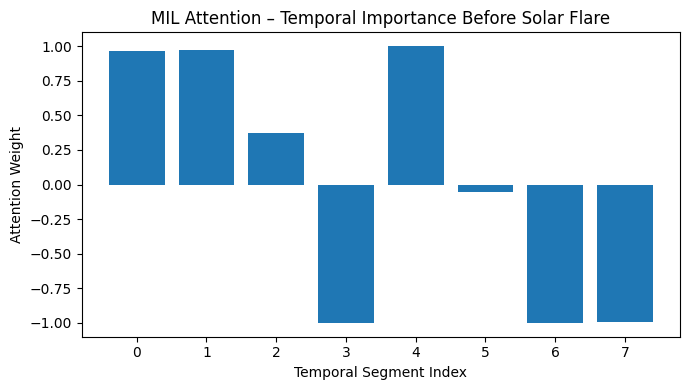

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(range(len(weights)), weights)
plt.xlabel("Temporal Segment Index")
plt.ylabel("Attention Weight")
plt.title("MIL Attention – Temporal Importance Before Solar Flare")
plt.tight_layout()
plt.savefig("../outputs/figures/mil_attention_bar.png", dpi=300)
plt.show()


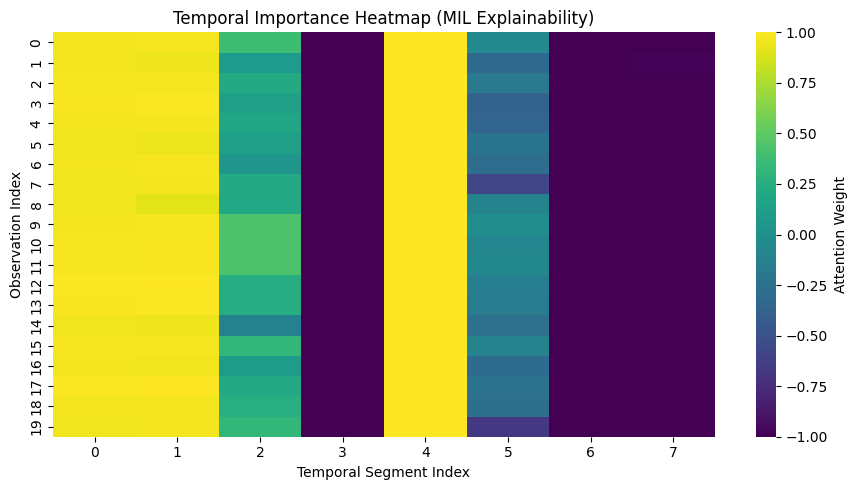

In [14]:
import seaborn as sns

attention_matrix = []

for i in range(20):
    w = attention_model.predict(X_bags[i:i+1], verbose=0)[0].squeeze()
    attention_matrix.append(w)

attention_matrix = np.array(attention_matrix)

plt.figure(figsize=(9,5))
sns.heatmap(
    attention_matrix,
    cmap="viridis",
    cbar_kws={"label": "Attention Weight"}
)
plt.xlabel("Temporal Segment Index")
plt.ylabel("Observation Index")
plt.title("Temporal Importance Heatmap (MIL Explainability)")
plt.tight_layout()
plt.savefig("../outputs/figures/temporal_attention_heatmap.png", dpi=300)
plt.show()


SHAP analysis reveals that a small subset of engineered solar features
dominates the model’s decision-making. These features correspond to
magnetic field variability and temporal instability, which are known
precursors of solar flare activity.


The MIL attention mechanism highlights specific temporal segments
prior to flare onset as most influential. This suggests that solar
flares exhibit gradual buildup patterns rather than instantaneous
events, aligning with physical understanding of solar activity.
